In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"D:\StudentsPerformance.csv")
print(df)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
completed=df[df["test preparation course"]=="completed"]["math score"]

In [11]:
not_completed=df[df["test preparation course"]=="none"]["math score"]

In [12]:
a=completed.mean()

In [13]:
b=not_completed.mean()

In [14]:
print("completed.mean:",a)

completed.mean: 69.69553072625699


In [15]:
print("not_completed.mean:",b)

not_completed.mean: 64.0778816199377


In [16]:
from scipy.stats import ttest_ind

In [17]:
t_stat,p_value=ttest_ind(completed,not_completed)

In [18]:
print("T-statistic:",t_stat)

T-statistic: 5.704616417349102


In [19]:
print("P-value:",p_value)

P-value: 1.5359134607147415e-08


In [20]:
if p_value<0.05:
    print("Reject null hypothesis")
else:
    print("fail to reject null hypoyhesis")

Reject null hypothesis


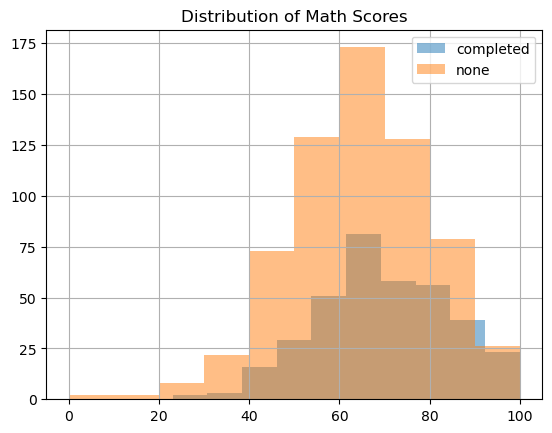

In [21]:
df.groupby("test preparation course")["math score"].hist(alpha=0.5, legend=True)
plt.title("Distribution of Math Scores")
plt.show()

In [25]:
import scipy.stats as stats

In [26]:
print(stats.shapiro(completed))
print(stats.shapiro(not_completed))

ShapiroResult(statistic=np.float64(0.9936613643190316), pvalue=np.float64(0.13934941590125344))
ShapiroResult(statistic=np.float64(0.9921171200614826), pvalue=np.float64(0.0017542243871878584))


In [27]:
w_stat, p_val_levene = stats.levene(completed, not_completed)
print("Levene's test p-value:", p_val_levene)

Levene's test p-value: 0.4655125071689348
